# **Aprendizaje no supervizado**

**K_Means**

El algoritmo de K-Means es uno de los más usados a la hora de aplicar Clustering, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.



Generamos un data sintetico



In [231]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

n_centers = random.randint(1, 20)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)

from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)

Se generaron 18
Coordenadas de los centroides:
[[ 6.58751315  4.41877719]
 [-1.72212825 -4.66275477]
 [ 1.28526199 -4.31416939]
 [ 3.28482841 -6.8450539 ]
 [-7.48725311 -2.94694745]
 [-1.8952943  -7.37083122]
 [-8.21740639 -5.84158289]
 [ 3.48917383  2.55543876]
 [ 9.69636392 -5.55347781]
 [ 1.71159262  1.14991719]
 [ 8.24172974  1.29935169]
 [ 3.70039834  7.01186948]
 [ 0.82645126  9.82562672]
 [ 6.24301356  8.2148012 ]
 [ 8.79316849  5.36879886]
 [ 7.49375377 -4.30826978]
 [-0.48319054  3.97178554]
 [-5.61704934 -1.74104286]]


* graficamos los centroides


In [232]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

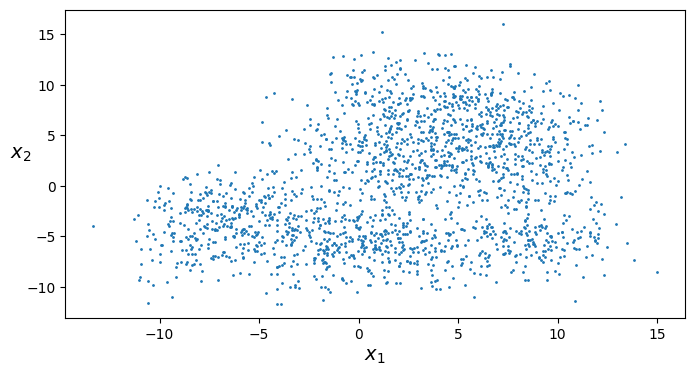

In [233]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

# **En Scikit-Learn puedes usar el objeto KMeans, indicando el número de clusters deseado.**

scikit-learn buscaremos comportmientos similares para poder agruparlos

etiqueta los datos a cada grupo de acuerdo a la cantidad que se almaceno en blob_centers

In [234]:
from sklearn.cluster import KMeans
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([12,  2,  0, ..., 14, 17,  7], dtype=int32)

Mostramos lo centros de los clusters





In [235]:
kmeans.cluster_centers_

array([[-8.49401184, -6.70667749],
       [ 9.58123942,  3.94714848],
       [ 2.35847904,  0.7234556 ],
       [-3.31355724, -0.68382973],
       [ 5.14137996,  9.70205996],
       [ 5.57452804,  3.05592736],
       [ 2.8750259 ,  5.86261032],
       [10.2058437 , -5.84430366],
       [-1.86534361, -7.96322201],
       [ 0.77509386, -4.6062884 ],
       [-7.62725889, -2.14893103],
       [-0.94504575,  3.94840713],
       [ 0.64425464,  9.78983946],
       [-4.04575513, -4.52295939],
       [ 3.41544734, -7.52987884],
       [ 8.58911501, -0.53606483],
       [ 6.58266554, -5.11373504],
       [ 7.82083262,  7.09613407]])

Ingresamos nuevos datos para ver a que grupos les asigna

In [239]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([11,  2, 11, 11], dtype=int32)

**Graficamos los grupos con sus centros encotrados**

In [240]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

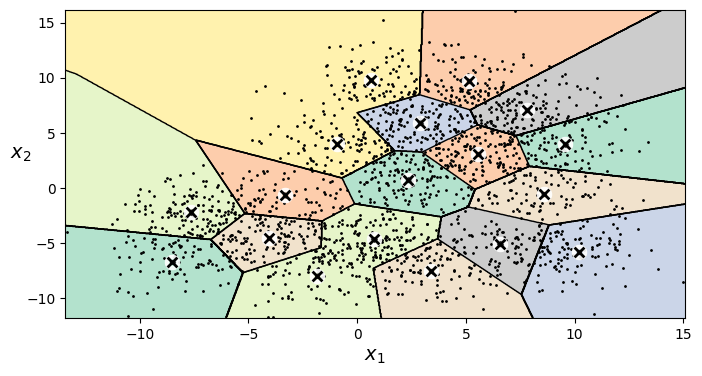

In [241]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

Ahora con este codigo mostramos las distancia exacta que tienen los datos nuevos ingresados a cada centro de los grupos

In [243]:
kmeans.transform(X_new)

array([[12.16365365,  9.77709241,  2.68178839,  4.26410643,  9.2604274 ,
         5.67365362,  4.81513576, 12.87215388, 10.13633561,  6.65160259,
         8.68266704,  2.16550267,  7.81643544,  7.67574972, 10.12343179,
         8.95569771,  9.69209532,  9.33466686],
       [14.41938075,  6.86324264,  1.42867588,  6.86031683,  7.99420014,
         2.7826565 ,  3.86463154, 10.6516329 , 11.08771217,  6.97088616,
        11.40842935,  4.39996322,  8.13825135,  9.60164905,  9.53893009,
         6.13757537,  7.9649682 ,  7.01505592],
       [11.15364308, 12.61684095,  5.82202302,  3.6971502 , 10.54512567,
         8.57471043,  6.53532456, 15.89389868, 11.02178215,  8.49158153,
         6.92264513,  2.26325276,  7.70600492,  7.59529603, 12.3303006 ,
        12.116573  , 12.5562803 , 11.57016564],
       [10.72133744, 12.66419457,  5.6452996 ,  3.19923271, 10.86976243,
         8.59253084,  6.76927452, 15.6211943 , 10.52456459,  8.04678001,
         6.5592747 ,  2.51410425,  8.14999088,  7.100

Este código sirve para tomar "fotos" del algoritmo en el paso 2 y en el paso 3, y así poder graficar y ver cómo se va acomodando los centros poco a poco.

* init="k-means++" (El truco de inicio): En lugar
de poner los centros al azar, usa una estrategia inteligente para separarlos bien desde el primer segundo. Esto hace que el algoritmo termine más rápido.

* algorithm="elkan" (El motor de carreras): Es un truco matemático que usa la geometría para evitar medir distancias innecesarias. Hace que el código corra al doble de velocidad.

In [248]:
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=1, random_state=4)

# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

KMeans(algorithm='elkan', max_iter=3, n_clusters=18, n_init=1, random_state=5)

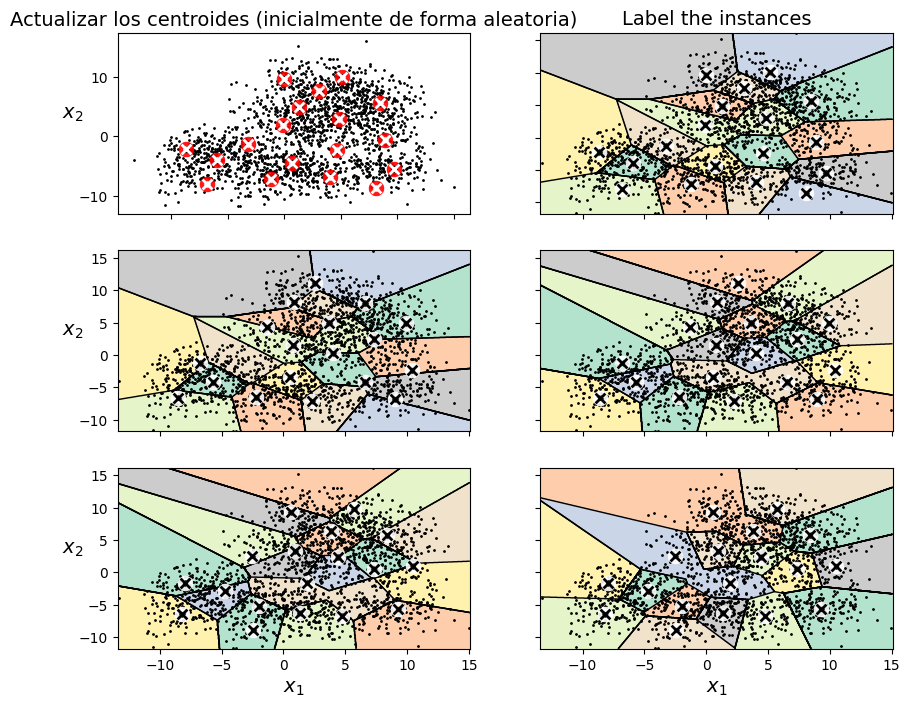

In [249]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Actualizar los centroides (inicialmente de forma aleatoria)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra

In [250]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

Aquí se crean dos modelos de K-Means forzados a realizar una sola iteración de búsqueda (n_init=1) partiendo de puntos aleatorios. Al cambiar la semilla (random_state), demostramos el gran defecto de K-Means: el azar del inicio provoca que un modelo encuentre una solución distinta (y potencialmente mala) a la del otro.

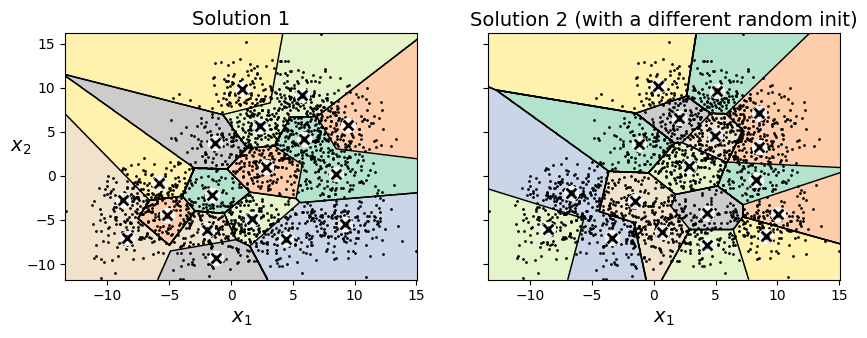

In [251]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Esta es la continuación y solución al problema anterior. En lugar de jugárnosla a una sola oportunidad, configuramos n_init=10. El algoritmo realiza 10 intentos independientes con inicios aleatorios diferentes en segundo plano, evalúa cuál logró la menor distancia interna (menor Inercia) y nos devuelve automáticamente el mejor resultado posible, logrando un mapa mucho más estable y óptimo.

In [252]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)        # inicializando 10 y quedandome con el mejor resultado
kmeans_rnd_10_inits.fit(X)

KMeans(algorithm='elkan', init='random', n_clusters=18, n_init=10,
       random_state=11)

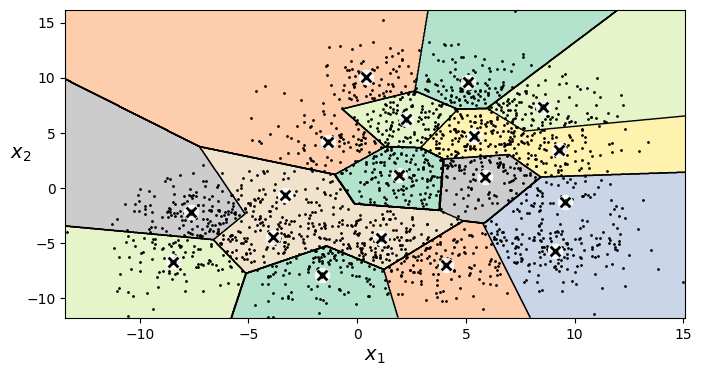

In [253]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

## **Optimización para Grandes Volúmenes de Datos**
### **Implementación de Mini-Batch K-Means con el Dataset MNIST**
Otras mejoras al algoritmo de K-Means incluyen: K-Means acelerados (usado por Scikit-Learn por defecto y que evita algunos cálculos de distancias) y mini-batch K-Means (que puedes usarse si el dataset es tan grande que no cabe en memoria). Vamos a ver un ejemplo de este último caso con el dataset MNIST, para lo cual usaremos el objeto MiniBatchKMeans.

Descarga e importa el dataset MNIST, que contiene 70,000 imágenes de dígitos del 0 al 9 escritos a mano. También convierte las etiquetas (los números reales que representa cada imagen) a un formato numérico entero de 64 bits (np.int64).

In [254]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
mnist.target = mnist.target.astype(np.int64)

dividimos el data set en datos de entrenamiento y prueba

In [255]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    mnist["data"], mnist["target"], random_state=42)

se crea un funcion que seleccion filas de manera aleatoria y sin repetir, para no pasrle directamentelas miles de imagenes

In [256]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

El código lanza 10 modelos independientes. Cada uno entrena 100 veces con pedacitos de 100 imágenes. Al final de cada modelo, se mide su error en la recta final del entrenamiento, y el código se asegura de que la variable best_kmeans apunte únicamente al modelo que tuvo los grupos más compactos y perfectos.

In [257]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None # aqui creamosS variable para guardar el mejor modelo entrenado
# el entrenamiento de Mini-bacht kmeans
for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [258]:
best_kmeans.score(X)

-25075.52648276429

El algoritmo de mini-batch K-Means es más rápido que K-Means normal, pero su precisión suele ser peor.

### Encontrando el número óptimo de grupos

In [259]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.338396645126844)

Calculando la métrica para diferentes números de clusters podemos encontrar el valor óptimo.

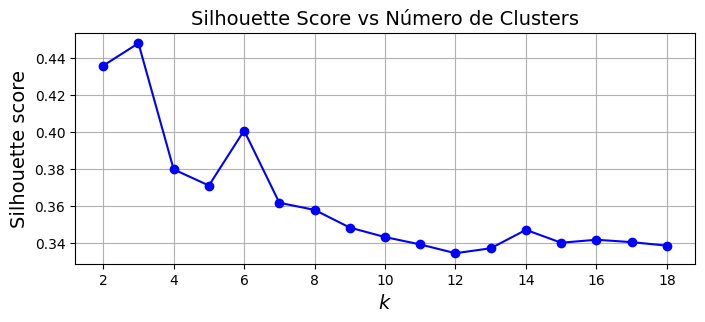

In [260]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

# **Metodo del codo**

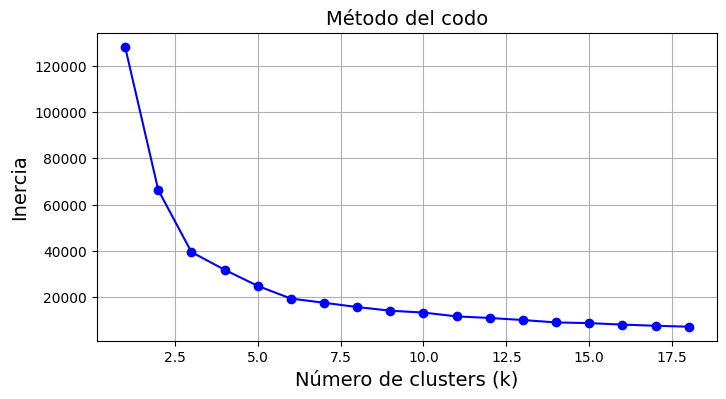

In [261]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()

# **Diagrama de silueta por bloques**

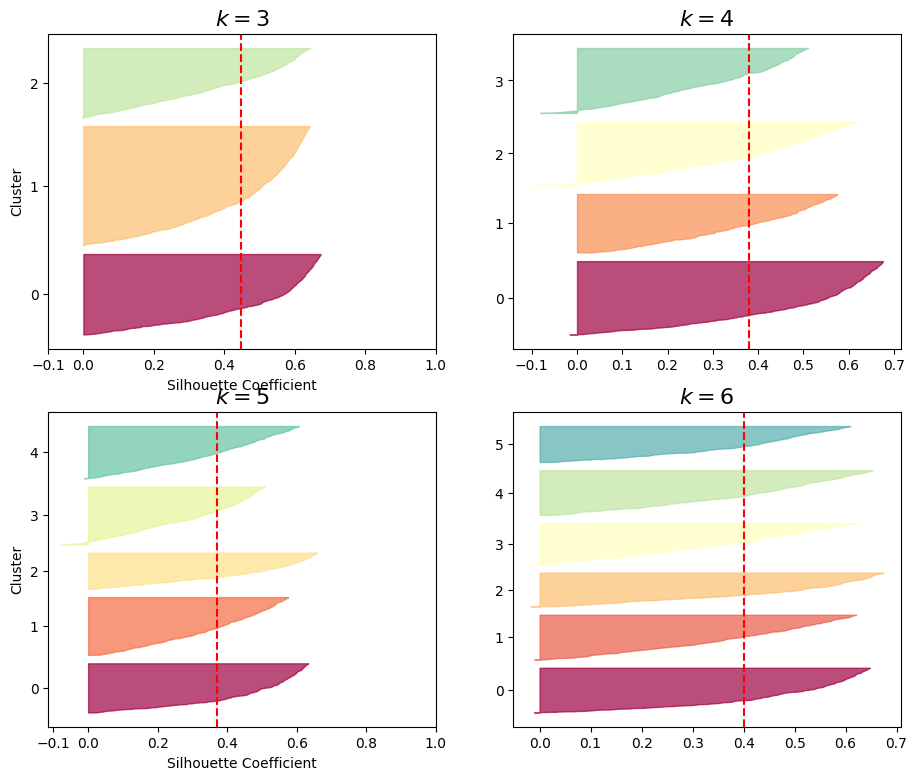

In [262]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores


    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    #if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    #else:
        #plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

aqui mostramos todas las siluetas grupos posibles que encontro el modelo

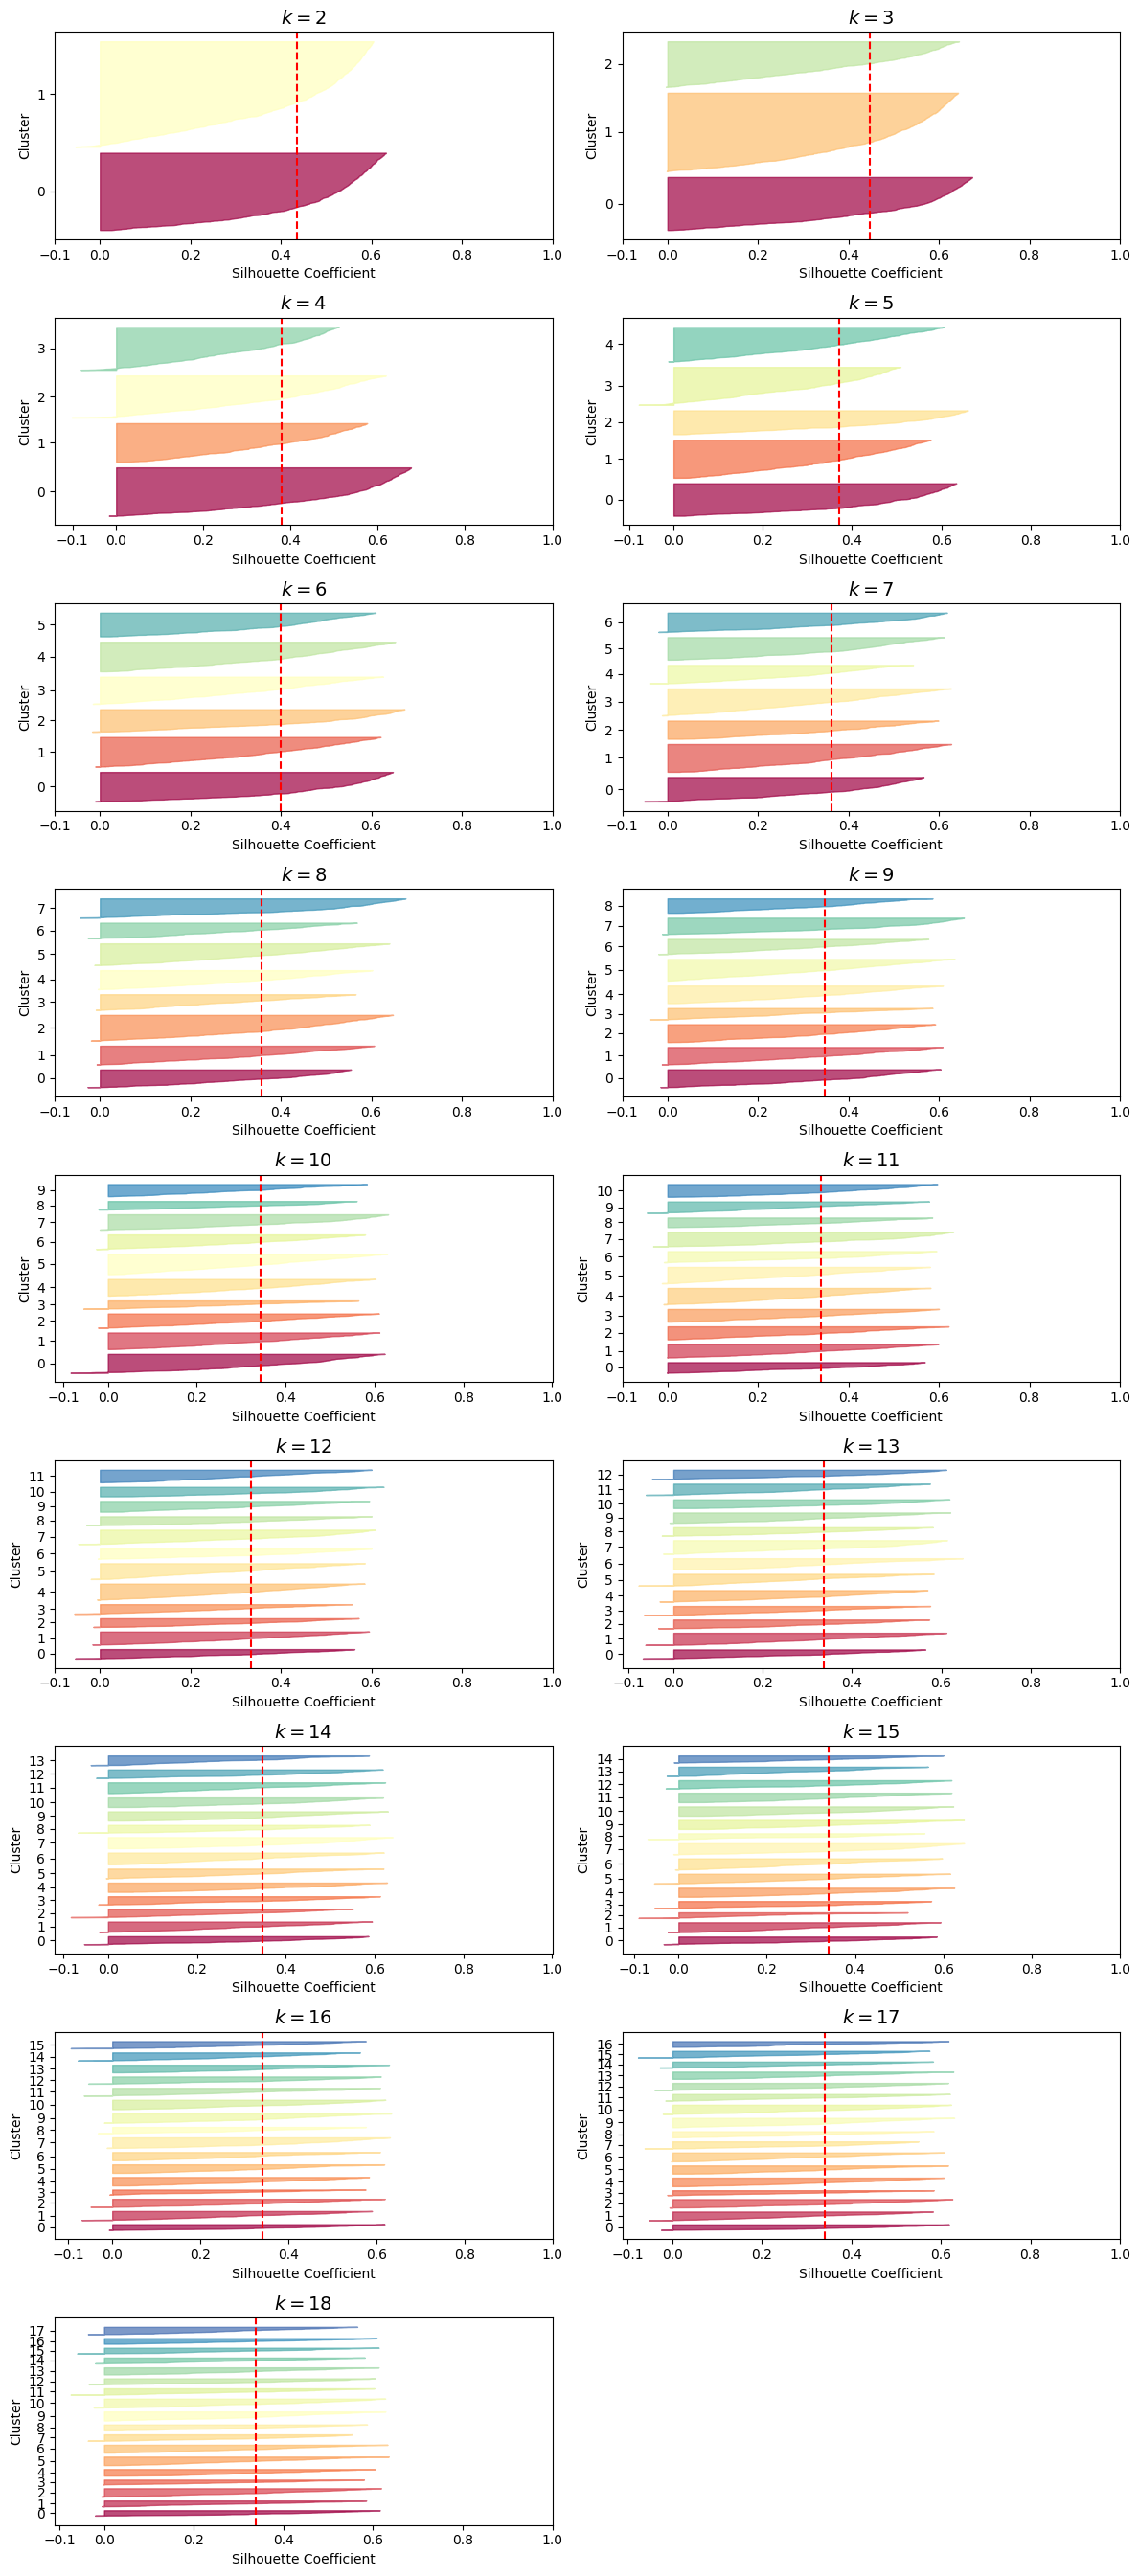

In [263]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------

---------------------------------------------------------------------------------------------------------------------------------------------



# **K-MEANS para el aprendizaje SEMI-SUPERVISADO**

* **Aplicacion del metodo del CODO y SILHOUETTE SCORE**

